# Machine Learning Pipelines with scikit-learn

This notebook shows how to use `sklearn.pipeline.Pipeline` and why it matters in real machine learning work.

The example is a synthetic marketplace-order risk model. Each order has numeric features, categorical features, missing values, and many decoy columns that contain no real signal. That lets us demonstrate a common mistake: fitting preprocessing or feature selection before cross-validation, which lets validation folds influence the preparation steps and makes the score look better than it really is.

We will build a pipeline that:

- imputes missing values;
- scales numeric features;
- one-hot encodes categorical features;
- selects useful features;
- trains a logistic regression classifier;
- tunes preprocessing and model parameters together;
- predicts on raw new orders, including missing values and unseen categories.


In [1]:
import os
import tempfile
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", tempfile.gettempdir())

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42

pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)

plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "figure.figsize": (9, 5),
    "font.size": 11,
})

warnings.filterwarnings("ignore", category=FutureWarning)


## 1. Create a Mixed-Type Classification Dataset

The dataset represents orders that may need manual fraud review. It is synthetic and fully offline, but it includes ingredients that real tabular ML pipelines have to handle:

- numeric columns with different scales;
- categorical columns;
- missing values;
- a moderately imbalanced target;
- many random decoy columns that should not help the model.

The decoy columns make the pipeline lesson more concrete. If we use labels to select features before cross-validation, some random columns will look useful by chance and the validation estimate becomes too optimistic.


In [2]:
def sigmoid(values):
    return 1 / (1 + np.exp(-values))


def make_marketplace_order_data(n_rows=1_200, n_decoy_features=200, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)

    order_amount = rng.lognormal(mean=3.65, sigma=0.75, size=n_rows)
    account_age_days = rng.gamma(shape=2.0, scale=90, size=n_rows)
    failed_logins_7d = rng.poisson(0.45 + 1.2 * (account_age_days < 20), size=n_rows)
    distance_from_usual_km = (
        rng.gamma(shape=2.0, scale=18, size=n_rows)
        + rng.exponential(scale=35, size=n_rows) * (rng.random(n_rows) < 0.12)
    )
    order_hour = rng.integers(0, 24, size=n_rows)
    device_age_days = rng.gamma(shape=1.5, scale=65, size=n_rows)
    support_contacts_30d = rng.poisson(0.25 + 0.5 * (order_amount > 80), size=n_rows)

    shipping_speed = rng.choice(
        ["standard", "express", "same_day"],
        size=n_rows,
        p=[0.55, 0.30, 0.15],
    )
    device_type = rng.choice(
        ["desktop", "mobile", "tablet", "new_device"],
        size=n_rows,
        p=[0.34, 0.38, 0.16, 0.12],
    )
    payment_method = rng.choice(
        ["card", "paypal", "bank_transfer", "prepaid"],
        size=n_rows,
        p=[0.52, 0.24, 0.14, 0.10],
    )
    customer_segment = rng.choice(
        ["new", "returning", "vip"],
        size=n_rows,
        p=[0.28, 0.60, 0.12],
    )
    region = rng.choice(
        ["north", "south", "east", "west"],
        size=n_rows,
        p=[0.25, 0.25, 0.25, 0.25],
    )
    coupon_used = rng.choice(
        ["none", "small", "large"],
        size=n_rows,
        p=[0.68, 0.23, 0.09],
    )

    risk_score = (
        -2.00
        + 0.010 * (order_amount - 45)
        - 0.0045 * account_age_days
        + 0.32 * failed_logins_7d
        + 0.006 * distance_from_usual_km
        + 0.012 * (100 - device_age_days)
        + 0.22 * support_contacts_30d
        + 0.34 * (shipping_speed == "same_day")
        + 0.42 * (device_type == "new_device")
        + 0.35 * (payment_method == "prepaid")
        + 0.22 * (customer_segment == "new")
        + 0.18 * (coupon_used == "large")
        + 0.25 * ((order_hour <= 5) | (order_hour >= 23))
        + rng.normal(0, 1.0, size=n_rows)
    )
    needs_manual_review = rng.binomial(1, sigmoid(risk_score))

    signal_features = pd.DataFrame({
        "order_amount": order_amount.round(2),
        "account_age_days": account_age_days.round(1),
        "failed_logins_7d": failed_logins_7d,
        "distance_from_usual_km": distance_from_usual_km.round(1),
        "order_hour": order_hour,
        "device_age_days": device_age_days.round(1),
        "support_contacts_30d": support_contacts_30d,
        "shipping_speed": shipping_speed,
        "device_type": device_type,
        "payment_method": payment_method,
        "customer_segment": customer_segment,
        "region": region,
        "coupon_used": coupon_used,
    })

    decoy_features = pd.DataFrame(
        rng.normal(size=(n_rows, n_decoy_features)),
        columns=[f"decoy_{index:03d}" for index in range(n_decoy_features)],
    )

    X = pd.concat([signal_features, decoy_features], axis=1)

    missing_rates = {
        "order_amount": 0.05,
        "device_age_days": 0.08,
        "payment_method": 0.03,
        "region": 0.03,
    }
    for column, rate in missing_rates.items():
        X.loc[rng.random(n_rows) < rate, column] = np.nan

    y = pd.Series(needs_manual_review, name="needs_manual_review")
    return X, y


X, y = make_marketplace_order_data()
decoy_features = [column for column in X.columns if column.startswith("decoy_")]
signal_features = [column for column in X.columns if column not in decoy_features]
data = X.assign(needs_manual_review=y)

display(data[signal_features + ["needs_manual_review"]].head())

display(pd.DataFrame({
    "rows": [len(X)],
    "features": [X.shape[1]],
    "signal_features": [len(signal_features)],
    "decoy_features": [len(decoy_features)],
    "manual_review_rate": [y.mean()],
}))


,order_amount,account_age_days,failed_logins_7d,distance_from_usual_km,order_hour,device_age_days,support_contacts_30d,shipping_speed,device_type,payment_method,customer_segment,region,coupon_used,needs_manual_review
0,48.35,42.8,1,63.6,2,64.6,0,standard,tablet,prepaid,vip,south,none,1
1,17.64,204.3,1,52.6,15,383.2,0,express,mobile,card,new,north,none,0
2,67.55,86.4,1,37.9,20,25.8,0,standard,mobile,paypal,new,south,none,0
3,77.90,81.5,1,34.6,14,NaN,0,express,mobile,card,returning,east,none,1
4,8.91,601.9,2,32.9,17,19.0,0,standard,desktop,paypal,returning,south,large,0


,rows,features,signal_features,decoy_features,manual_review_rate
0,1200,213,13,200,0.1817


In [3]:
missing_summary = (
    X[signal_features]
    .isna()
    .mean()
    .mul(100)
    .rename("missing_percent")
    .to_frame()
    .query("missing_percent > 0")
    .sort_values("missing_percent", ascending=False)
)

missing_summary


,missing_percent
device_age_days,7.4167
order_amount,4.8333
payment_method,3.4167
region,3.0833


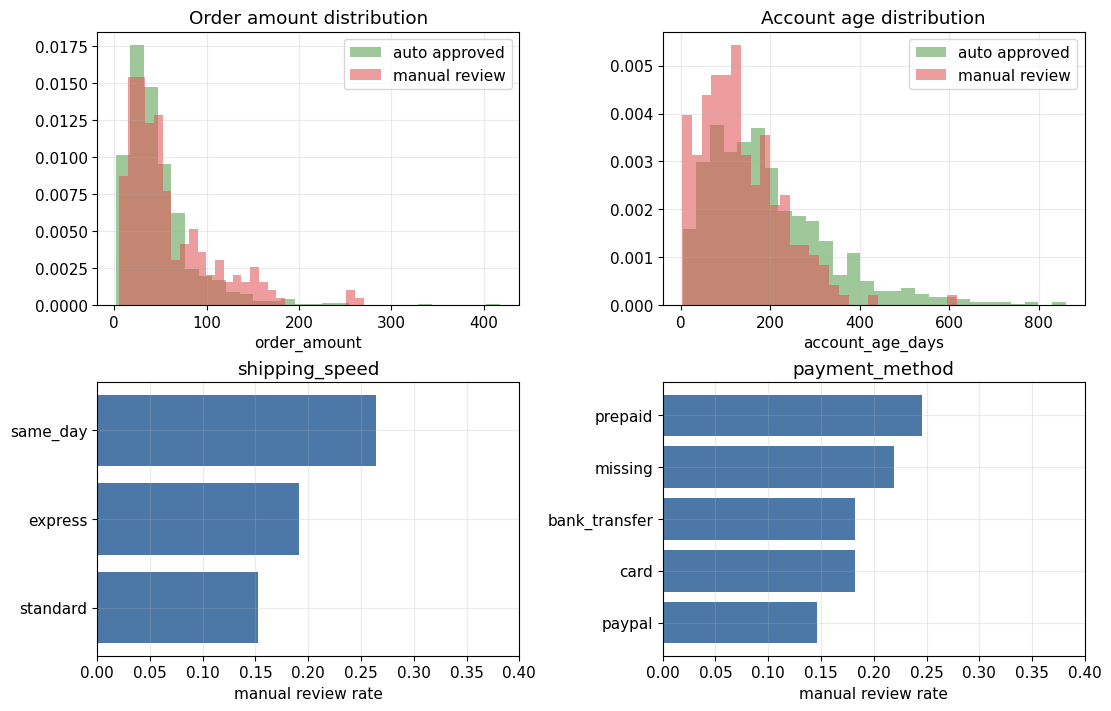

In [4]:
def plot_rate_by_category(ax, column):
    rates = data.groupby(column, dropna=False)["needs_manual_review"].mean().sort_values()
    labels = ["missing" if pd.isna(value) else str(value) for value in rates.index]
    ax.barh(labels, rates.values, color="#4C78A8")
    ax.set_xlim(0, max(0.40, rates.max() + 0.05))
    ax.set_xlabel("manual review rate")
    ax.set_title(column)


fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)

for target_value, label, color in [
    (0, "auto approved", "#59A14F"),
    (1, "manual review", "#E15759"),
]:
    subset = data.loc[data["needs_manual_review"] == target_value, "order_amount"].dropna()
    axes[0, 0].hist(subset, bins=28, alpha=0.58, density=True, label=label, color=color)
axes[0, 0].set_title("Order amount distribution")
axes[0, 0].set_xlabel("order_amount")
axes[0, 0].legend(frameon=True)

for target_value, label, color in [
    (0, "auto approved", "#59A14F"),
    (1, "manual review", "#E15759"),
]:
    subset = data.loc[data["needs_manual_review"] == target_value, "account_age_days"].dropna()
    axes[0, 1].hist(subset, bins=28, alpha=0.58, density=True, label=label, color=color)
axes[0, 1].set_title("Account age distribution")
axes[0, 1].set_xlabel("account_age_days")
axes[0, 1].legend(frameon=True)

plot_rate_by_category(axes[1, 0], "shipping_speed")
plot_rate_by_category(axes[1, 1], "payment_method")

plt.show()


## 2. Define the Pipeline Building Blocks

A pipeline turns the whole workflow into one estimator. That matters because every step obeys the same `fit`, `transform`, and `predict` contract.

For this dataset we need two preprocessing paths:

- numeric columns: median imputation, then scaling;
- categorical columns: most-frequent imputation, then one-hot encoding.

The `ColumnTransformer` applies those paths to the right columns. The outer `Pipeline` then chains preprocessing, feature selection, and the classifier.


In [5]:
numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = [column for column in X.columns if column not in numeric_features]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

pd.DataFrame({
    "split": ["train", "test"],
    "rows": [len(X_train), len(X_test)],
    "manual_review_rate": [y_train.mean(), y_test.mean()],
})


,split,rows,manual_review_rate
0,train,900,0.1822
1,test,300,0.1800


In [6]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def make_preprocessor():
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder()),
    ])

    return ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ])


def make_classifier(C=1.0):
    return LogisticRegression(
        C=C,
        class_weight="balanced",
        max_iter=2_000,
        random_state=RANDOM_STATE,
        solver="liblinear",
    )


def make_review_pipeline(k=20, C=1.0):
    return Pipeline(steps=[
        ("preprocess", make_preprocessor()),
        ("select", SelectKBest(score_func=f_classif, k=k)),
        ("model", make_classifier(C=C)),
    ])


set_config(display="diagram")
review_pipeline = make_review_pipeline(k=20, C=1.0)
review_pipeline


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['order_amount',
                                                   'account_age_days',
                                                   'failed_logins_7d',
                                                   'distance_from_usual_km',
                                                   'order_hour',
                                                   'device_age_days',
                                                   'support_contacts_30d',
                                                   'decoy_000', 'decoy_001',
                                                   'decoy_002', 'decoy_003',
                                                   'decoy_00...
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['shipping_speed',
                                                   'device_type',
                                                   'payment_method',
                                                   'customer_segment', 'region',
                                                   'coupon_used'])])),
                ('select', SelectKBest(k=20)),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42, solver='liblinear'))])

## 3. Why Pipeline Matters: Validation Leakage

Cross-validation is supposed to simulate future data by repeatedly hiding one fold from training.

A common mistake is to do preprocessing or feature selection once before cross-validation. In this notebook, `SelectKBest` uses the target values to choose columns. If we fit it before cross-validation, it has already seen the labels from every validation fold. With many decoy columns, some random columns look predictive by chance, so the cross-validation score becomes inflated.

The correct pattern is to put the target-aware step inside a `Pipeline`. Then each fold fits the imputer, scaler, encoder, selector, and model only on that fold's training rows.


In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}

# Incorrect validation pattern: preprocessing and feature selection are fit once
# on the full training set before the cross-validation folds are created.
bad_preprocessor = make_preprocessor()
bad_selector = SelectKBest(score_func=f_classif, k=20)
X_train_prepared = bad_preprocessor.fit_transform(X_train, y_train)
X_train_selected = bad_selector.fit_transform(X_train_prepared, y_train)

bad_cv = cross_validate(
    make_classifier(),
    X_train_selected,
    y_train,
    cv=cv,
    scoring=scoring,
)

# Correct validation pattern: the same steps live inside Pipeline, so each fold
# fits preprocessing and feature selection only on that fold's training rows.
correct_cv = cross_validate(
    make_review_pipeline(k=20, C=1.0),
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
)


def summarize_cv(result, label):
    return {
        "workflow": label,
        "cv_roc_auc_mean": result["test_roc_auc"].mean(),
        "cv_roc_auc_std": result["test_roc_auc"].std(),
        "cv_avg_precision_mean": result["test_average_precision"].mean(),
        "cv_avg_precision_std": result["test_average_precision"].std(),
    }


cv_comparison = pd.DataFrame([
    summarize_cv(bad_cv, "bad: fit preprocessing + SelectKBest before CV"),
    summarize_cv(correct_cv, "good: Pipeline fits every step inside each fold"),
])

cv_comparison


,workflow,cv_roc_auc_mean,cv_roc_auc_std,cv_avg_precision_mean,cv_avg_precision_std
0,bad: fit preprocessing + SelectKBest before CV,0.7639,0.0608,0.4246,0.0794
1,good: Pipeline fits every step inside each fold,0.6682,0.0630,0.3005,0.0549


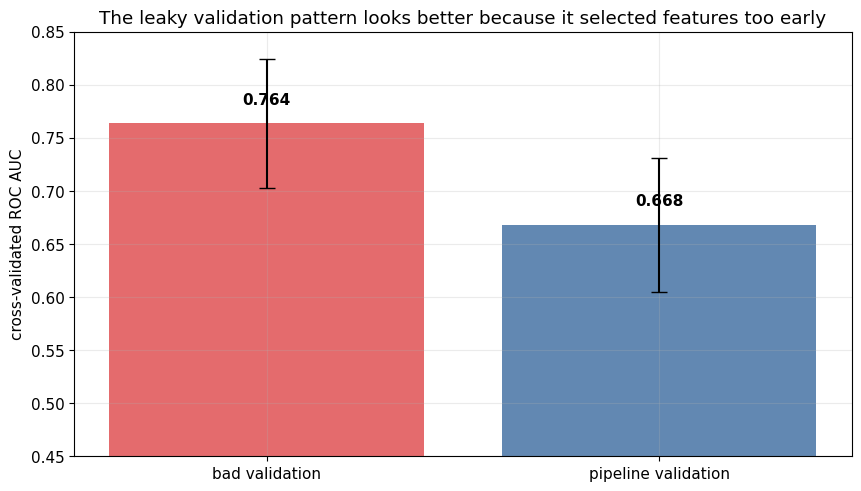

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
positions = np.arange(len(cv_comparison))
ax.bar(
    positions,
    cv_comparison["cv_roc_auc_mean"],
    yerr=cv_comparison["cv_roc_auc_std"],
    color=["#E15759", "#4C78A8"],
    alpha=0.88,
    capsize=6,
)
ax.set_xticks(positions)
ax.set_xticklabels(["bad validation", "pipeline validation"])
ax.set_ylim(0.45, 0.85)
ax.set_ylabel("cross-validated ROC AUC")
ax.set_title("The leaky validation pattern looks better because it selected features too early")
for index, value in enumerate(cv_comparison["cv_roc_auc_mean"]):
    ax.text(index, value + 0.018, f"{value:.3f}", ha="center", fontweight="bold")
plt.show()


The bad workflow can still train a final model, but its cross-validation estimate is not trustworthy. The held-out test set gives us a reality check because it was not used during the preprocessing or feature-selection steps.


In [9]:
bad_final_model = make_classifier().fit(X_train_selected, y_train)
bad_test_scores = bad_final_model.predict_proba(
    bad_selector.transform(bad_preprocessor.transform(X_test))
)[:, 1]

review_pipeline = make_review_pipeline(k=20, C=1.0)
review_pipeline.fit(X_train, y_train)
pipeline_test_scores = review_pipeline.predict_proba(X_test)[:, 1]

holdout_comparison = pd.DataFrame([
    {
        "workflow": "bad workflow final model",
        "cv_roc_auc_estimate": bad_cv["test_roc_auc"].mean(),
        "test_roc_auc": roc_auc_score(y_test, bad_test_scores),
        "test_avg_precision": average_precision_score(y_test, bad_test_scores),
    },
    {
        "workflow": "pipeline final model",
        "cv_roc_auc_estimate": correct_cv["test_roc_auc"].mean(),
        "test_roc_auc": roc_auc_score(y_test, pipeline_test_scores),
        "test_avg_precision": average_precision_score(y_test, pipeline_test_scores),
    },
])

holdout_comparison


,workflow,cv_roc_auc_estimate,test_roc_auc,test_avg_precision
0,bad workflow final model,0.7639,0.6904,0.3068
1,pipeline final model,0.6682,0.6904,0.3068


## 4. Inspect What the Pipeline Learned

A fitted pipeline stores the learned state of every step:

- imputer medians and most-frequent values;
- scaling means and standard deviations;
- one-hot categories;
- selected feature mask;
- classifier coefficients.

This makes the preprocessing reproducible. The same transformations used during training are used during prediction.


In [10]:
def get_preprocessed_feature_names(fitted_preprocessor):
    try:
        return fitted_preprocessor.get_feature_names_out()
    except Exception:
        cat_pipeline = fitted_preprocessor.named_transformers_["cat"]
        onehot = cat_pipeline.named_steps["onehot"]
        if hasattr(onehot, "get_feature_names_out"):
            cat_names = onehot.get_feature_names_out(categorical_features)
        else:
            cat_names = onehot.get_feature_names(categorical_features)
        return np.array(
            [f"num__{column}" for column in numeric_features]
            + [f"cat__{name}" for name in cat_names]
        )


feature_names = get_preprocessed_feature_names(review_pipeline.named_steps["preprocess"])
selector = review_pipeline.named_steps["select"]
model = review_pipeline.named_steps["model"]
selected_mask = selector.get_support()

selected_features = pd.DataFrame({
    "feature": feature_names[selected_mask],
    "anova_score": selector.scores_[selected_mask],
    "coefficient": model.coef_[0],
})
selected_features["source"] = np.where(
    selected_features["feature"].str.contains("decoy_"),
    "decoy/noise",
    "signal or category",
)
selected_features["abs_coefficient"] = selected_features["coefficient"].abs()

selected_features.sort_values("anova_score", ascending=False).head(20)


,feature,anova_score,coefficient,source,abs_coefficient
1,num__account_age_days,32.7920,-0.7433,signal or category,0.7433
3,num__device_age_days,30.4019,-0.6973,signal or category,0.6973
18,cat__shipping_speed_standard,13.0271,-0.4603,signal or category,0.4603
17,cat__shipping_speed_same_day,10.2640,0.2164,signal or category,0.2164
2,num__failed_logins_7d,8.8884,0.1957,signal or category,0.1957
11,num__decoy_108,7.6925,0.2778,decoy/noise,0.2778
0,num__order_amount,7.6546,0.2305,signal or category,0.2305
13,num__decoy_122,7.0917,-0.2360,decoy/noise,0.2360
4,num__support_contacts_30d,6.9912,0.2347,signal or category,0.2347
15,num__decoy_169,6.5141,0.3112,decoy/noise,0.3112


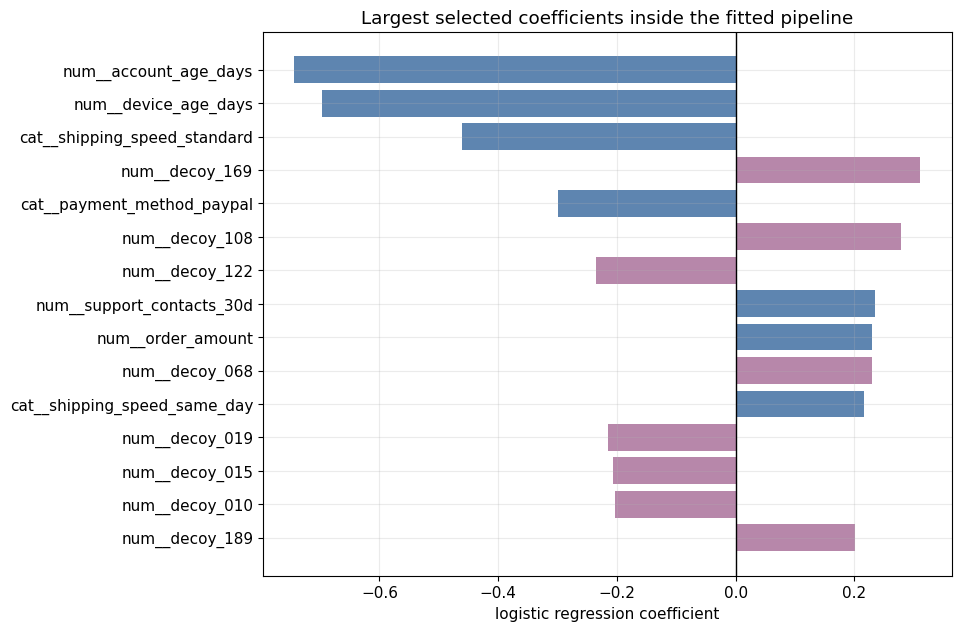

In [11]:
top_features = selected_features.sort_values("abs_coefficient", ascending=False).head(15).iloc[::-1]
colors = np.where(top_features["source"] == "decoy/noise", "#B07AA1", "#4C78A8")

fig, ax = plt.subplots(figsize=(9.5, 6.2), constrained_layout=True)
ax.barh(top_features["feature"], top_features["coefficient"], color=colors, alpha=0.9)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("logistic regression coefficient")
ax.set_title("Largest selected coefficients inside the fitted pipeline")
plt.show()


## 5. Tune the Whole Workflow with GridSearchCV

`GridSearchCV` works with pipelines because each step exposes parameters through the `step__parameter` naming pattern.

Here we tune:

- `select__k`: how many preprocessed features to keep;
- `model__C`: logistic regression regularization strength.

Because the selector is inside the pipeline, every candidate is evaluated without leaking validation-fold labels into feature selection.


In [12]:
param_grid = {
    "select__k": [10, 20, 35],
    "model__C": [0.2, 1.0, 3.0],
}

grid_search = GridSearchCV(
    estimator=make_review_pipeline(),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,
)
grid_search.fit(X_train, y_train)

grid_results = (
    pd.DataFrame(grid_search.cv_results_)[[
        "param_select__k",
        "param_model__C",
        "mean_test_score",
        "std_test_score",
        "rank_test_score",
    ]]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

display(grid_results)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validated ROC AUC: {grid_search.best_score_:.3f}")


,param_select__k,param_model__C,mean_test_score,std_test_score,rank_test_score
0,10,3.0,0.6720,0.0565,1
1,10,1.0,0.6715,0.0562,2
2,10,0.2,0.6706,0.0570,3
3,20,1.0,0.6682,0.0630,4
4,20,0.2,0.6677,0.0629,5
5,20,3.0,0.6677,0.0630,6
6,35,1.0,0.6635,0.0515,7
7,35,3.0,0.6632,0.0519,8
8,35,0.2,0.6632,0.0515,9


Best parameters: {'model__C': 3.0, 'select__k': 10}
Best cross-validated ROC AUC: 0.672


## 6. Evaluate the Best Pipeline on the Held-Out Test Set

Now we evaluate exactly once on the test set. The test set was not used to choose the preprocessing, the selected features, or the model hyperparameters.


In [13]:
best_pipeline = grid_search.best_estimator_
y_pred = best_pipeline.predict(X_test)
y_score = best_pipeline.predict_proba(X_test)[:, 1]

metrics = pd.DataFrame({
    "metric": [
        "roc_auc",
        "average_precision",
        "accuracy",
        "precision",
        "recall",
        "f1",
    ],
    "value": [
        roc_auc_score(y_test, y_score),
        average_precision_score(y_test, y_score),
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
    ],
})

metrics


,metric,value
0,roc_auc,0.7109
1,average_precision,0.3458
2,accuracy,0.6367
3,precision,0.2835
4,recall,0.6667
5,f1,0.3978


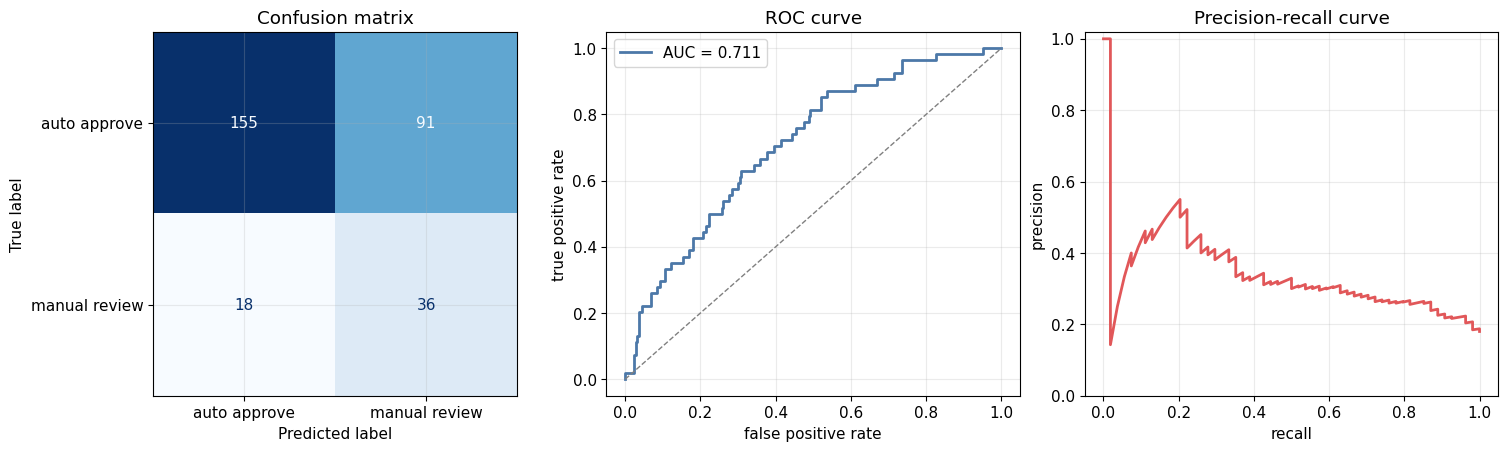

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), constrained_layout=True)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["auto approve", "manual review"],
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion matrix")

fpr, tpr, _ = roc_curve(y_test, y_score)
axes[1].plot(fpr, tpr, color="#4C78A8", linewidth=2, label=f"AUC = {roc_auc_score(y_test, y_score):.3f}")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
axes[1].set_xlabel("false positive rate")
axes[1].set_ylabel("true positive rate")
axes[1].set_title("ROC curve")
axes[1].legend(frameon=True)

precision, recall, _ = precision_recall_curve(y_test, y_score)
axes[2].plot(recall, precision, color="#E15759", linewidth=2)
axes[2].set_xlabel("recall")
axes[2].set_ylabel("precision")
axes[2].set_title("Precision-recall curve")
axes[2].set_ylim(0, 1.02)

plt.show()


## 7. Use the Pipeline on Raw New Orders

A fitted pipeline accepts the same raw columns used during training. The caller does not have to remember the imputation values, scaling statistics, one-hot category order, selected columns, or coefficient alignment.

The batch below intentionally includes missing values and categories that were not seen during training. `OneHotEncoder(handle_unknown="ignore")` keeps the prediction call from failing on those new categories.


In [15]:
new_orders = X_test.sample(4, random_state=RANDOM_STATE).copy()
new_orders.loc[new_orders.index[0], "shipping_speed"] = "overnight"
new_orders.loc[new_orders.index[1], "payment_method"] = "crypto_wallet"
new_orders.loc[new_orders.index[2], "device_age_days"] = np.nan
new_orders.loc[new_orders.index[3], "region"] = "central"

new_order_scores = best_pipeline.predict_proba(new_orders)[:, 1]
new_order_predictions = best_pipeline.predict(new_orders)

review_columns = [
    "order_amount",
    "account_age_days",
    "failed_logins_7d",
    "distance_from_usual_km",
    "shipping_speed",
    "device_type",
    "payment_method",
    "region",
]

new_order_report = new_orders[review_columns].copy()
new_order_report["predicted_review_probability"] = new_order_scores
new_order_report["prediction"] = np.where(new_order_predictions == 1, "manual review", "auto approve")

new_order_report


,order_amount,account_age_days,failed_logins_7d,distance_from_usual_km,shipping_speed,device_type,payment_method,region,predicted_review_probability,prediction
234,22.27,80.5,0,76.0,overnight,mobile,card,south,0.2883,auto approve
1063,89.94,74.5,0,12.0,standard,mobile,crypto_wallet,west,0.5208,manual review
688,27.27,381.0,0,80.8,express,new_device,prepaid,south,0.1768,auto approve
761,61.96,101.8,0,18.3,standard,new_device,bank_transfer,central,0.4395,auto approve


## 8. Save and Reload the Whole Workflow

Because the pipeline is one fitted object, it can be saved and loaded as one artifact. The loaded object still contains all preprocessing state and can score raw orders immediately.


In [16]:
with tempfile.TemporaryDirectory() as tmpdir:
    model_path = Path(tmpdir) / "marketplace_review_pipeline.joblib"
    joblib.dump(best_pipeline, model_path)
    loaded_pipeline = joblib.load(model_path)
    loaded_scores = loaded_pipeline.predict_proba(new_orders)[:, 1]

pd.DataFrame({
    "score_before_save": new_order_scores,
    "score_after_reload": loaded_scores,
    "absolute_difference": np.abs(new_order_scores - loaded_scores),
})


,score_before_save,score_after_reload,absolute_difference
0,0.2883,0.2883,0.0
1,0.5208,0.5208,0.0
2,0.1768,0.1768,0.0
3,0.4395,0.4395,0.0


## Key Takeaways

`Pipeline` is important because it makes the modeling workflow honest and repeatable.

- It prevents validation leakage by fitting preprocessing and target-aware steps only on the training portion of each split.
- It keeps training-time and prediction-time preprocessing identical.
- It makes cross-validation and hyperparameter search evaluate the whole workflow, not only the final estimator.
- It packages the fitted preprocessing state and model into one object that can be saved, loaded, and reused on raw data.

When a workflow has imputation, scaling, encoding, feature selection, dimensionality reduction, or any learned preprocessing step, the default should be to put it inside a pipeline.
